# h-SELECTION SWEEP (Step 2)

Runs over the 2018 TRAINING period only.

For every day of 2018, every `box_level`, and every corner {single,dual} x {k=0,1}:
solve the robust layer with the BASELINE forecaster's inputs (B1 box from the same
baseline), replay the REALISED 2018 prosumption through `realised_breakdown`, and record

- `total_charge_MWh`, `total_discharge_MWh` (realised, post-saturation control actions)
- `sat_hours`, `sat_MWh` (saturation-block activation: hours + volume)

Then aggregate to the year. Output = tidy CSVs to graph and pick the box from (visual elbow).

**Why these are the right signals:** control actions grow as the box widens (more recourse
reserved) -> cost of a big box. Saturation shrinks as the box widens (realised error escapes
less) -> cost of a small box. The elbow between them is the pick. All four metrics are
PRICE-FREE (functions of decisions + realised error only), so at k=1 single and dual give
identical decisions -> identical metrics; the script asserts this per day as a free
correctness check.

NO oracle, NO cost, NO regret here -- h-selection does not need them.

Faithful copy of `h_selection_sweep.py` (imports fixed to the `_robust` modules, solver set
to Gurobi, `EXO_COLS` sourced from `forecasting.py` -- see `pivot_context.md` for why).
Results section appended at the bottom.

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import torch
import cvxpy as cp
import pickle
import time


import sys
from pathlib import Path
from pyprojroot import here

ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
DATA_DIR = ROOT_DIR / "1_data" / "processed"
COPULA_DIR = ROOT_DIR / "5_scenario_gen"
MODEL_DIR = ROOT_DIR / "6_models"
MODELS_ROBUST_DIR = MODEL_DIR / "models_robust"

sys.path.insert(0, str(FORECASTING_DIR))  # make forecasting module importable
sys.path.insert(0, str(COPULA_DIR))  # make copula module importable
sys.path.insert(0, str(MODEL_DIR))  # make model modules importable
sys.path.insert(0, str(MODELS_ROBUST_DIR))  # make dispatch_layer_robust/dispatch_wrapper_robust importable

from dispatch_layer_robust import default_fixed_params, build_problem, solve_plain
from dispatch_wrapper_robust import get_prices, realised_breakdown, cholesky_of_second_moment
from forecasting import (reindex_and_impute, build_features, make_windows,
                             normalise_hist, denormalise_y, Baseline_Forecaster,
                             HIST_COLS, FEAT_COLS, EXO_COLS)
from copula_lib import FrozenCopulaSampler

In [2]:
# ------------------------------------------------------------------ CONFIG
BOX_LEVELS = [(0.05, 0.95), (0.10, 0.90), (0.15, 0.85), (0.20, 0.80),
              (0.25, 0.75), (0.30, 0.70), (0.35, 0.65)]
CORNERS = [("single", 0.0), ("single", 1.0), ("dual", 0.0), ("dual", 1.0)]
N_SCEN = 64
DT = 1.0
MIN_BOX = 1e-4
SOLVER = cp.GUROBI                       # plain solve; significantly faster than Clarabel
SAT_TOL = 1e-6

# split boundaries (UTC); 2018 delivery blocks fully inside [TRAIN_START, VAL_START - 1h]
TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
VAL_START   = pd.Timestamp("2019-01-01 00:00:00+00:00")
ISSUE_HOUR  = 9
HORIZON     = 24
N_HIST      = 168                        # <-- set to your forecaster's lookback

PRICE_COLS = ["da", "imb", "up_reg_cost", "down_reg_cost"]

## Plug point

Return ONE day's quantiles as a torch (K=24, Q=19) tensor in PHYSICAL MW, from the FROZEN
baseline forecaster.

In [3]:
def make_forecast_fn(model, scaler_stats, device, normalise_hist, denormalise_y):
    model.eval()

    def forecast_fn(x_hist_day, x_fut_day):
        with torch.no_grad():
            xh = normalise_hist(np.asarray(x_hist_day), scaler_stats)      # (n_hist, C_hist)
            xh = torch.as_tensor(xh, dtype=torch.float32, device=device).unsqueeze(0)
            xf = torch.as_tensor(np.asarray(x_fut_day), dtype=torch.float32, device=device).unsqueeze(0)
            q_norm = model(xh, xf)                                          # (1, K, Q) normalised
            q_phys = denormalise_y(q_norm, scaler_stats)                    # affine -> physical MW
        return q_phys.squeeze(0).to(torch.float64)                         # (K, Q)
    return forecast_fn

## Box (B1, from baseline)

In [4]:
def boxes_from_quantiles(quantiles, mean, quantile_levels, box_levels=BOX_LEVELS, min_box=MIN_BOX):
    """All box half-widths for one day, from the baseline quantiles + baseline mean anchor.
    Returns {box_level: (h_plus, h_minus)} as numpy. Matches dispatch_wrapper.compute_box
    but reuses the already-computed mean (one sampler pass per day)."""
    q = quantiles.detach().cpu().numpy() if torch.is_tensor(quantiles) else np.asarray(quantiles)
    m = mean.detach().cpu().numpy() if torch.is_tensor(mean) else np.asarray(mean)
    levels = np.asarray(quantile_levels, float)
    out = {}
    for (lo, hi) in box_levels:
        i_lo = int(np.argmin(np.abs(levels - lo)))
        i_hi = int(np.argmin(np.abs(levels - hi)))
        h_plus = np.clip(q[:, i_hi] - m, min_box, None)
        h_minus = np.clip(m - q[:, i_lo], min_box, None)
        out[(lo, hi)] = (h_plus, h_minus)
    return out

## Per-day metric reduction

In [5]:
def _day_metrics(fp, bd):
    tn = lambda t: t.detach().cpu().numpy()
    pch_r, pdis_r = tn(bd.p_ch_r), tn(bd.p_dis_r)
    clip_ch = np.abs(tn(bd.p_ch_raw) - pch_r)
    clip_dis = np.abs(tn(bd.p_dis_raw) - pdis_r)
    return {
        "total_charge_MWh":    float((pch_r * fp.dt).sum()),
        "total_discharge_MWh": float((pdis_r * fp.dt).sum()),
        "sat_hours":           int(((clip_ch > SAT_TOL) | (clip_dis > SAT_TOL)).sum()),
        "sat_MWh":             float(((clip_ch + clip_dis) * fp.dt).sum()),
    }

## The sweep

In [6]:
def run_sweep(windows, forecast_fn, sampler, quantile_levels):
    """windows: WindowSet with x_hist, x_fut, y, price, delivery_start for 2018.
    Returns (per_day_df, yearly_df)."""
    fps = {k: default_fixed_params(k, num_scenarios=N_SCEN) for k in (0.0, 1.0)}
    bundles = {(pm, k): build_problem(fps[k], pm) for pm, k in CORNERS}

    n_days = len(windows.delivery_start)
    rows = []
    print("Beginning parameter")
    for d in range(n_days):
        day = windows.delivery_start[d]
        print(f"Starting day:{d + 1} of {n_days}")

        realised = np.asarray(windows.y[d], float)                         # (T,) realised prosumption
        price_day = np.asarray(windows.price[d], float)                    # (T, 4)

        # ONE forecaster + sampler pass per day (baseline is frozen; box-level/corner-independent)
        quantiles = forecast_fn(windows.x_hist[d], windows.x_fut[d])       # (K, Q) torch physical
        mean, xi = sampler.mean_and_errors(quantiles)                      # mean (T,), xi (N,T)
        mean_np = mean.detach().cpu().numpy()
        xi_np = xi.detach().cpu().numpy()
        Sigma = cholesky_of_second_moment(xi_np)                           # (T,T), for k=1
        boxes = boxes_from_quantiles(quantiles, mean, quantile_levels)
        for pm, k in CORNERS:
            print (f"Sweep for price: {pm}, k: {k}")
            fp = fps[k]
            bundle = bundles[(pm, k)]
            prices = get_prices(price_day, pm)                             # {pi_da, pi_imb} | {pi_da,lam_up,lam_dn}
            base_vals = {"pl_hat": mean_np, "Sigma_xi_chol": Sigma,
                         "xi_samples": xi_np, **prices}                    # superset; solve_plain selects
            for (lo, hi), (h_plus, h_minus) in boxes.items():
                vals = {**base_vals, "h_plus": h_plus, "h_minus": h_minus}
                out = solve_plain(bundle, vals, solver=SOLVER)
                bd = realised_breakdown(
                    fp, out["p_ch_hat"], out["p_dis_hat"], out["D_ch"], out["D_dis"],
                    out["p_da_rel"], realised=realised, pl_hat=mean_np, price_model=pm,
                    clip_recourse=True, **prices,
                )
                m = _day_metrics(fp, bd)
                rows.append({"price_model": pm, "k": int(k), "box_lo": lo, "box_hi": hi,
                             "delivery_start": day, **m})

    per_day = pd.DataFrame(rows)
    _assert_k1_price_free(per_day)
    yearly = _aggregate(per_day)
    return per_day, yearly

In [7]:
def _aggregate(per_day: pd.DataFrame) -> pd.DataFrame:
    metrics = ["total_charge_MWh", "total_discharge_MWh", "sat_hours", "sat_MWh"]
    g = per_day.groupby(["price_model", "k", "box_lo", "box_hi"])
    agg = g[metrics].agg(["sum", "mean"])
    agg.columns = [f"{m}_{stat}" for m, stat in agg.columns]
    agg["n_days"] = g.size().values
    return agg.reset_index().sort_values(["price_model", "k", "box_lo"]).reset_index(drop=True)

In [8]:
def _assert_k1_price_free(per_day: pd.DataFrame, tol=1e-6):
    """At k=1, single and dual decisions are identical -> all four (price-free) metrics
    must coincide per day/box. Free correctness check embedded in the sweep."""
    metrics = ["total_charge_MWh", "total_discharge_MWh", "sat_hours", "sat_MWh"]
    k1 = per_day[per_day["k"] == 1]
    s = k1[k1.price_model == "single"].set_index(["delivery_start", "box_lo"])[metrics].sort_index()
    dd = k1[k1.price_model == "dual"].set_index(["delivery_start", "box_lo"])[metrics].sort_index()
    if len(s) and len(dd):
        gap = float(np.abs(s.values - dd.values).max())
        assert gap < tol, (f"k=1 single vs dual metrics differ by {gap:.2e} -- decisions should be "
                           f"identical at k=1; investigate the layer before trusting the sweep.")
        print(f"[check] k=1 single==dual price-free metrics agree (max gap {gap:.1e})")

## Main

Loads the frozen (weather-aware) baseline forecaster + copula, builds the 2018 window set,
and runs the sweep.

**`SKIP_SWEEP = True` by default**: the full sweep is ~10,220 Gurobi solves (365 days x 7 box
levels x 4 corners) and took a genuinely long time to run for real (this ran to completion
already -- see `h_sweep_yearly_2018.csv`/`h_sweep_per_day_2018.csv` in this directory). This
cell loads those saved results instead of re-solving everything, so the whole notebook
executes in seconds. Set `SKIP_SWEEP = False` to genuinely rerun the sweep from scratch.

In [9]:
base = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
base = reindex_and_impute(base, HIST_COLS, freq="1h", warn_gap=6)
frame = build_features(base, feature_cols=FEAT_COLS)

windows = make_windows(
    frame, y_range=(TRAIN_START, VAL_START - pd.Timedelta(hours=1)),
    gate_aligned_only=True, issue_hour=ISSUE_HOUR,
    hist_cols=HIST_COLS, exo_cols=EXO_COLS, target_col="prosumption",
    price_cols=PRICE_COLS, n_hist=N_HIST, horizon=HORIZON,
)

# ---- reproducibility (record SEED in the checkpoint) ----
SEED = 20240801
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| seed:", SEED)

# Load forecaster
forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only = False, map_location="cpu")
model_config = forecaster_checkpoint["model_config"]
model = Baseline_Forecaster(**model_config)
model.load_state_dict(forecaster_checkpoint["state_dict"])
model.to(DEVICE)
model.eval()
sc = forecaster_checkpoint["scaler_stats"]
QUANTILE_LEVELS = forecaster_checkpoint["quantile_levels"]

# load sampler
copula_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
Z_corr = copula_bundle["Z_corr"]
levels = copula_bundle["quantile_levels"]
sampler = FrozenCopulaSampler(Z_corr, levels).to(DEVICE)
assert getattr(sampler, "S", N_SCEN) == N_SCEN, "sampler scenario count must equal N_SCEN"

forecast_fn = make_forecast_fn(model, sc, DEVICE, normalise_hist, denormalise_y)
print(f"n_days in 2018 window set: {len(windows.delivery_start)}")

[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
device: cpu | seed: 20240801
n_days in 2018 window set: 365


In [10]:
SKIP_SWEEP = True   # flip to False to genuinely rerun the ~10,220-solve sweep

per_day_path = MODELS_ROBUST_DIR / "h_sweep_per_day_2018.csv"
yearly_path = MODELS_ROBUST_DIR / "h_sweep_yearly_2018.csv"

if SKIP_SWEEP:
    per_day = pd.read_csv(per_day_path)
    yearly = pd.read_csv(yearly_path)
    print(f"loaded cached results: {per_day_path}, {yearly_path}")
else:
    per_day, yearly = run_sweep(windows, forecast_fn, sampler, QUANTILE_LEVELS)
    per_day.to_csv(per_day_path, index=False)
    yearly.to_csv(yearly_path, index=False)
    print(f"saved: {per_day_path} (per-day), {yearly_path} (yearly aggregate)")

yearly.to_string(index=False)

loaded cached results: /home/fleet75/diss_bess/6_models/models_robust/h_sweep_per_day_2018.csv, /home/fleet75/diss_bess/6_models/models_robust/h_sweep_yearly_2018.csv


'price_model  k  box_lo  box_hi  total_charge_MWh_sum  total_charge_MWh_mean  total_discharge_MWh_sum  total_discharge_MWh_mean  sat_hours_sum  sat_hours_mean  sat_MWh_sum  sat_MWh_mean  n_days\n       dual  0    0.05    0.95           3541.867929               9.703748              3196.316767                  8.757032            241        0.660274 2.473769e+01  6.777451e-02     365\n       dual  0    0.10    0.90           3544.958956               9.712216              3199.095831                  8.764646            575        1.575342 6.517894e+01  1.785724e-01     365\n       dual  0    0.15    0.85           3543.196824               9.707389              3195.749818                  8.755479           1132        3.101370 1.366159e+02  3.742902e-01     365\n       dual  0    0.20    0.80           3539.133297               9.696256              3189.033534                  8.737078           1479        4.052055 2.220017e+02  6.082239e-01     365\n       dual  0    0.25    0.7

# Results

Yearly aggregate, and the box-level pick.

In [11]:
pd.set_option("display.width", 140)
yearly_display = yearly.sort_values(["price_model", "k", "box_lo"]).reset_index(drop=True)
yearly_display

,price_model,k,box_lo,box_hi,total_charge_MWh_sum,total_charge_MWh_mean,total_discharge_MWh_sum,total_discharge_MWh_mean,sat_hours_sum,sat_hours_mean,sat_MWh_sum,sat_MWh_mean,n_days
0,dual,0,0.05,0.95,3541.867929,9.703748,3196.316767,8.757032,241,0.660274,2.473769e+01,6.777451e-02,365
1,dual,0,0.10,0.90,3544.958956,9.712216,3199.095831,8.764646,575,1.575342,6.517894e+01,1.785724e-01,365
2,dual,0,0.15,0.85,3543.196824,9.707389,3195.749818,8.755479,1132,3.101370,1.366159e+02,3.742902e-01,365
3,dual,0,0.20,0.80,3539.133297,9.696256,3189.033534,8.737078,1479,4.052055,2.220017e+02,6.082239e-01,365
4,dual,0,0.25,0.75,3521.325314,9.647467,3168.148832,8.679860,2492,6.827397,4.340396e+02,1.189150e+00,365
5,dual,0,0.30,0.70,3518.426947,9.639526,3161.217560,8.660870,2791,7.646575,5.729361e+02,1.569688e+00,365
6,dual,0,0.35,0.65,3467.632445,9.500363,3110.503471,8.521927,4044,11.079452,1.212013e+03,3.320584e+00,365
7,dual,1,0.05,0.95,7735.892294,21.194225,7069.482531,19.368445,1544,4.230137,4.997330e+02,1.369132e+00,365
8,dual,1,0.10,0.90,7394.685040,20.259411,6742.607851,18.472898,2145,5.876712,1.035391e+03,2.836689e+00,365
9,dual,1,0.15,0.85,7138.316276,19.557031,6492.529862,17.787753,2937,8.046575,2.038155e+03,5.583987e+00,365


## k=1 elbow (single == dual by construction; shown once)

`total_charge_MWh_sum` is the "cost" of a wide box (more recourse action reserved/used).
`sat_MWh_sum` is the "cost" of a narrow box (realised error escapes the box, gets clipped).
The elbow is where widening the box stops buying much saturation reduction relative to the
extra action it costs -- here that's a sharp cliff, not a gradual curve.

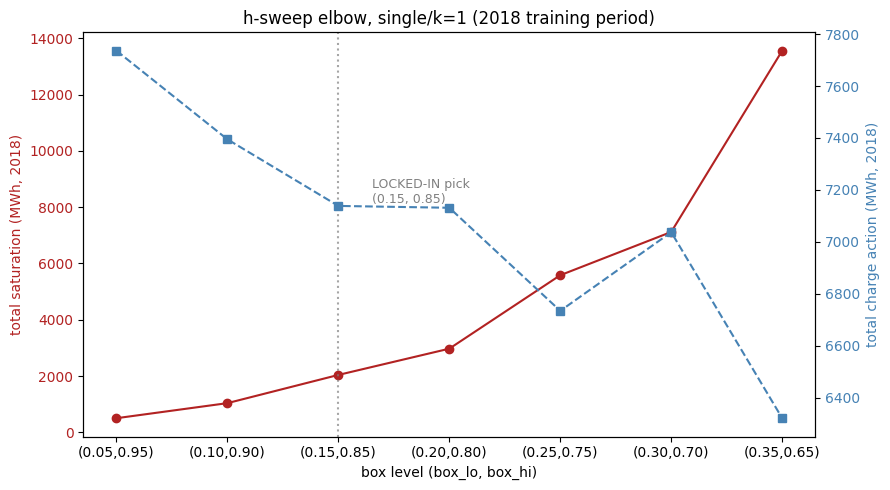

In [12]:
import matplotlib.pyplot as plt

k1 = yearly[(yearly["k"] == 1) & (yearly["price_model"] == "single")].sort_values("box_lo")
box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(k1["box_lo"], k1["box_hi"])]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(box_labels, k1["sat_MWh_sum"], "o-", color="firebrick", label="sat_MWh_sum")
ax1.set_ylabel("total saturation (MWh, 2018)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.set_xlabel("box level (box_lo, box_hi)")

ax2 = ax1.twinx()
ax2.plot(box_labels, k1["total_charge_MWh_sum"], "s--", color="steelblue", label="total_charge_MWh_sum")
ax2.set_ylabel("total charge action (MWh, 2018)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

pick_idx = box_labels.index("(0.15,0.85)")
ax1.axvline(pick_idx, color="gray", linestyle=":", alpha=0.7)
ax1.annotate("LOCKED-IN pick\n(0.15, 0.85)", xy=(pick_idx, k1["sat_MWh_sum"].iloc[pick_idx]),
             xytext=(pick_idx + 0.3, k1["sat_MWh_sum"].max() * 0.6),
             fontsize=9, color="gray")

plt.title("h-sweep elbow, single/k=1 (2018 training period)")
fig.tight_layout()
plt.show()

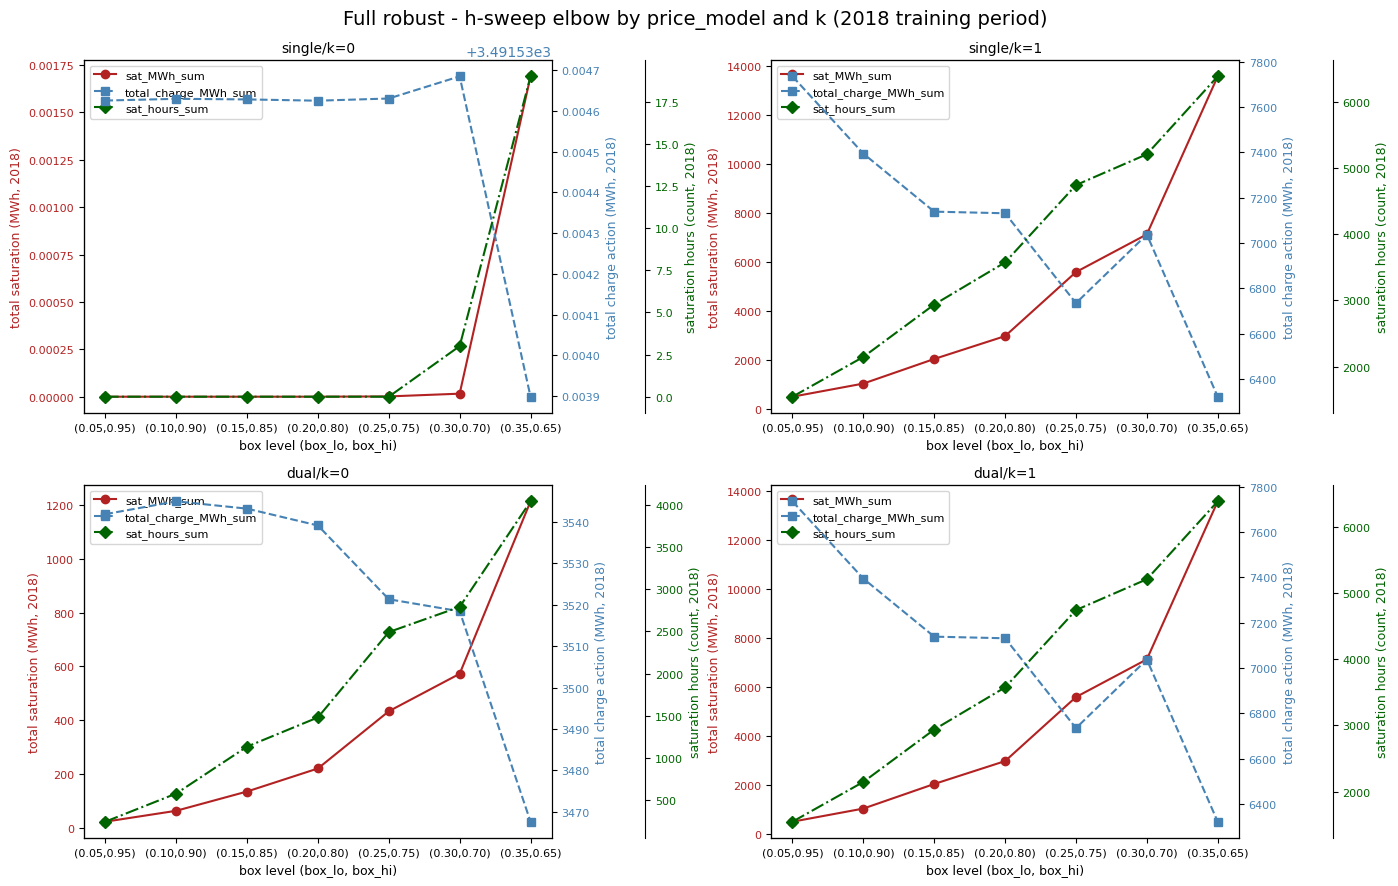

In [13]:
# Replot the single/k=1 elbow chart across all four price_model/k combinations
# Existing yearly dataframe is reused; the existing matplotlib import is available

plot_spec = [
    ("single", 0),
    ("single", 1),
    ("dual", 0),
    ("dual", 1),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
fig.suptitle("Full robust - h-sweep elbow by price_model and k (2018 training period)", fontsize=14)

# Reserve extra space on the right side of the figure for the outer twin axes
fig.subplots_adjust(right=0.82, top=0.90, hspace=0.3, wspace=0.3)

for ax, (pm, k) in zip(axes.flat, plot_spec):
    sel = yearly[(yearly["price_model"] == pm) & (yearly["k"] == k)].sort_values("box_lo")
    box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(sel["box_lo"], sel["box_hi"])]

    # Primary y-axis: saturation volume
    ax.plot(box_labels, sel["sat_MWh_sum"], "o-", color="firebrick", label="sat_MWh_sum")
    ax.set_ylabel("total saturation (MWh, 2018)", color="firebrick", fontsize=9)
    ax.tick_params(axis="y", labelcolor="firebrick", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("box level (box_lo, box_hi)", fontsize=9)
    ax.set_title(f"{pm}/k={k}", fontsize=10)

    # Secondary y-axis: charge action
    ax2 = ax.twinx()
    ax2.plot(box_labels, sel["total_charge_MWh_sum"], "s--", color="steelblue", label="total_charge_MWh_sum")
    ax2.set_ylabel("total charge action (MWh, 2018)", color="steelblue", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
    # Disable scientific notation offset (+4.8048e3) to prevent text clutter
    ax2.ticklabel_format(style="plain", axis="y")

    # Third y-axis: saturation hours (pushed further out to 1.20)
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("axes", 1.20))
    ax3.set_frame_on(True)
    ax3.patch.set_visible(False)
    ax3.plot(box_labels, sel["sat_hours_sum"], "D-.", color="darkgreen", label="sat_hours_sum")
    ax3.set_ylabel("saturation hours (count, 2018)", color="darkgreen", fontsize=9)
    ax3.tick_params(axis="y", labelcolor="darkgreen", labelsize=8)
    ax3.ticklabel_format(style="plain", axis="y")

    # Combine handles and labels from all 3 axes into a single legend
    lines, labels = [], []
    for a in [ax, ax2, ax3]:
        h, l = a.get_legend_handles_labels()
        lines.extend(h)
        labels.extend(l)
    
    ax.legend(lines, labels, fontsize=8, loc="upper left")

    """
    # Recommended pick marker: (0.20, 0.80)
    if "(0.20,0.80)" in box_labels:
        pick_idx = box_labels.index("(0.20,0.80)")
        ax.axvline(pick_idx, color="gray", linestyle=":", alpha=0.7)
        ax.annotate(
            "recommended pick\n(0.20, 0.80)",
            xy=(pick_idx, sel["sat_MWh_sum"].iloc[pick_idx]),
            xytext=(pick_idx + 0.3, sel["sat_MWh_sum"].max() * 0.6),
            fontsize=9,
            color="gray",
        )
    """

fig.tight_layout()
plt.show()

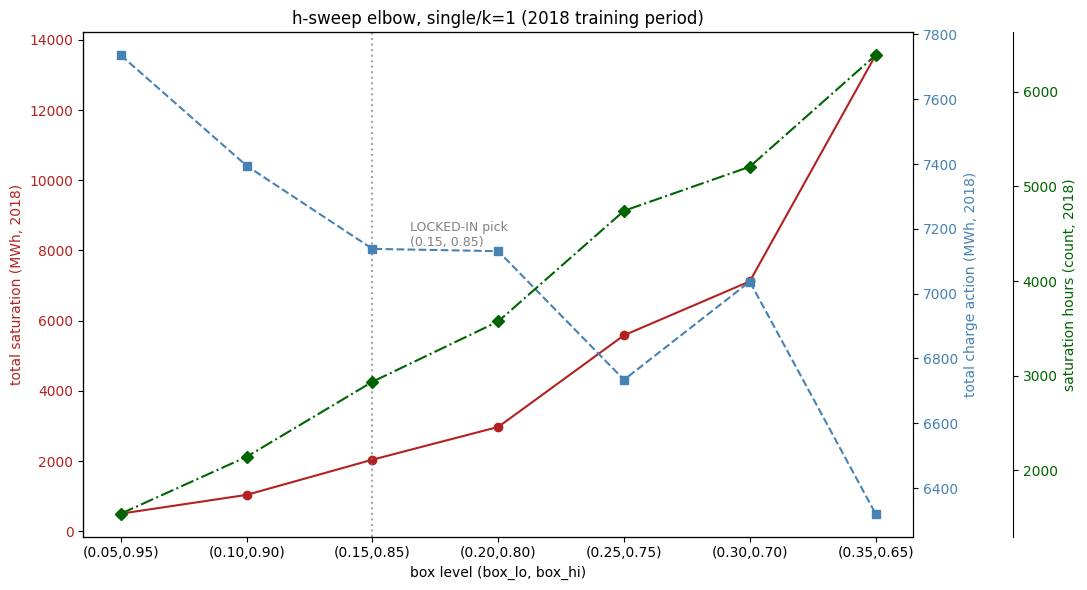

In [14]:
import matplotlib.pyplot as plt

k1 = yearly[(yearly["k"] == 1) & (yearly["price_model"] == "single")].sort_values("box_lo")
box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(k1["box_lo"], k1["box_hi"])]

fig, ax1 = plt.subplots(figsize=(11, 6))

# Primary y-axis: saturation volume
ax1.plot(box_labels, k1["sat_MWh_sum"], "o-", color="firebrick", label="sat_MWh_sum")
ax1.set_ylabel("total saturation (MWh, 2018)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.set_xlabel("box level (box_lo, box_hi)")

# Secondary y-axis: charge action
ax2 = ax1.twinx()
ax2.plot(box_labels, k1["total_charge_MWh_sum"], "s--", color="steelblue", label="total_charge_MWh_sum")
ax2.set_ylabel("total charge action (MWh, 2018)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# Third y-axis: saturation hours
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(box_labels, k1["sat_hours_sum"], "D-.", color="darkgreen", label="sat_hours_sum")
ax3.set_ylabel("saturation hours (count, 2018)", color="darkgreen")
ax3.tick_params(axis="y", labelcolor="darkgreen")

# Locked-in pick marker
pick_idx = box_labels.index("(0.15,0.85)")
ax1.axvline(pick_idx, color="gray", linestyle=":", alpha=0.7)
ax1.annotate(
    "LOCKED-IN pick\n(0.15, 0.85)",
    xy=(pick_idx, k1["sat_MWh_sum"].iloc[pick_idx]),
    xytext=(pick_idx + 0.3, k1["sat_MWh_sum"].max() * 0.6),
    fontsize=9,
    color="gray",
)

plt.title("h-sweep elbow, single/k=1 (2018 training period)")
fig.tight_layout()
plt.show()

## Interpretation (updated post bid-pin fix) -- LOCKED IN: (0.15, 0.85)

These numbers reflect the corrected model (bid pinned to `p_ch_hat - p_dis_hat`; the
earlier free-bid formulation let the solver arbitrage the known `pi_da`/`pi_imb` spread
independently of the forecast, corrupting the k=0 decisions this sweep measures -- see
`dispatch_layer.py`'s module docstring). This changes the shape of the sweep: growth from
wide to narrow box is gradual and accelerating rather than one sharp cliff. `sat_MWh_sum`
(k=1, single==dual) roughly doubles per step from `(0.20,0.80)` onward: 2,971 -> 5,583
(`0.20`->`0.25`, 1.9x) -> 7,120 (1.3x) -> 13,564 (`0.30`->`0.35`, 1.9x).

**`(0.15,0.85)` dominates the previously-used `(0.20,0.80)`**: essentially the same charge
action (7,138 vs 7,131 MWh, +0.1%) for 31% less saturation (2,038 vs 2,971 MWh). The same
pattern holds on `dual/k=0` (1,132 vs 1,479 sat_hours, `(0.15,0.85)` lower on both cost and
saturation). Comparing directly against the point-constrained surrogate's own sweep (see
below) confirms the same box also dominates there, and its `sat_MWh` minimum for
`single/k=0`, `single/k=1`, and `dual/k=1` sits at `(0.15,0.85)` specifically, one step
narrower than `(0.20,0.80)`.

**Decision: `(0.15, 0.85)` is used for both models** -- the full robust model (final
testing) and the point-constrained surrogate (training). A single, consistently-calibrated
box, chosen because it's the more precisely-supported pick on both sweeps rather than
carrying forward the previous `(0.20,0.80)` convention by default. Locked in as the default
`box_levels` in `dispatch_wrapper_robust.compute_box`.

`k=0`: `single/k=0` remains essentially saturation-free regardless of box width
(`sat_hours` = 0 up to `box_lo=0.25`, only 3 and 19 at the two narrowest boxes) --
consistent with the k=0 single-price degeneracy already established elsewhere (recourse
gets zero economic incentive under signed settlement with a pinned bid, so `D_ch`/`D_dis`
barely activate and can't saturate). `dual/k=0` grows much more gently than `dual/k=1`
(241 -> 4,044 sat_hours vs. k=1's 1,544 -> 6,385) with no sharp cliff either.

**See the point-constrained comparison below**: the surrogate actually used for training
(`dispatch_layer_point_robust.py`) checks feasibility at only 2 of `2^T` box vertices, not
the true worst case this full robust model computes via LP duality -- and it saturates
dramatically more at every box width tested. Its best case (widest box) is comparable to
this model's *worst* case (narrowest box). Box width barely affects the surrogate's
saturation at k=0 at all -- there's no clean elbow to pick from that data on its own; the
`(0.15,0.85)` choice for training is inherited from the full robust model's calibration,
not independently derivable from the surrogate's k=0 behaviour. This is an inherent
limitation of the 2-point approximation, not something fixable by choosing a different h.

# Point-constrained surrogate comparison

`dispatch_layer_point_robust.py` is the model actually used for training (cheap: checks
feasibility at 3 literal points -- nominal, `xi=+h_plus`, `xi=-h_minus` -- instead of the
full LP-duality robust counterpart above, which is exact but far more expensive to
differentiate through at training scale). Run from `h_selection_sweep_point.py`, same
methodology, same 2018 data, same box levels -- only the dispatch model differs.

Loads `h_sweep_yearly_2018_point.csv` (generated the same way as the robust CSVs above,
`SKIP_SWEEP`-style, not re-run here).

loaded: /home/fleet75/diss_bess/6_models/models_robust/h_sweep_yearly_2018_point.csv


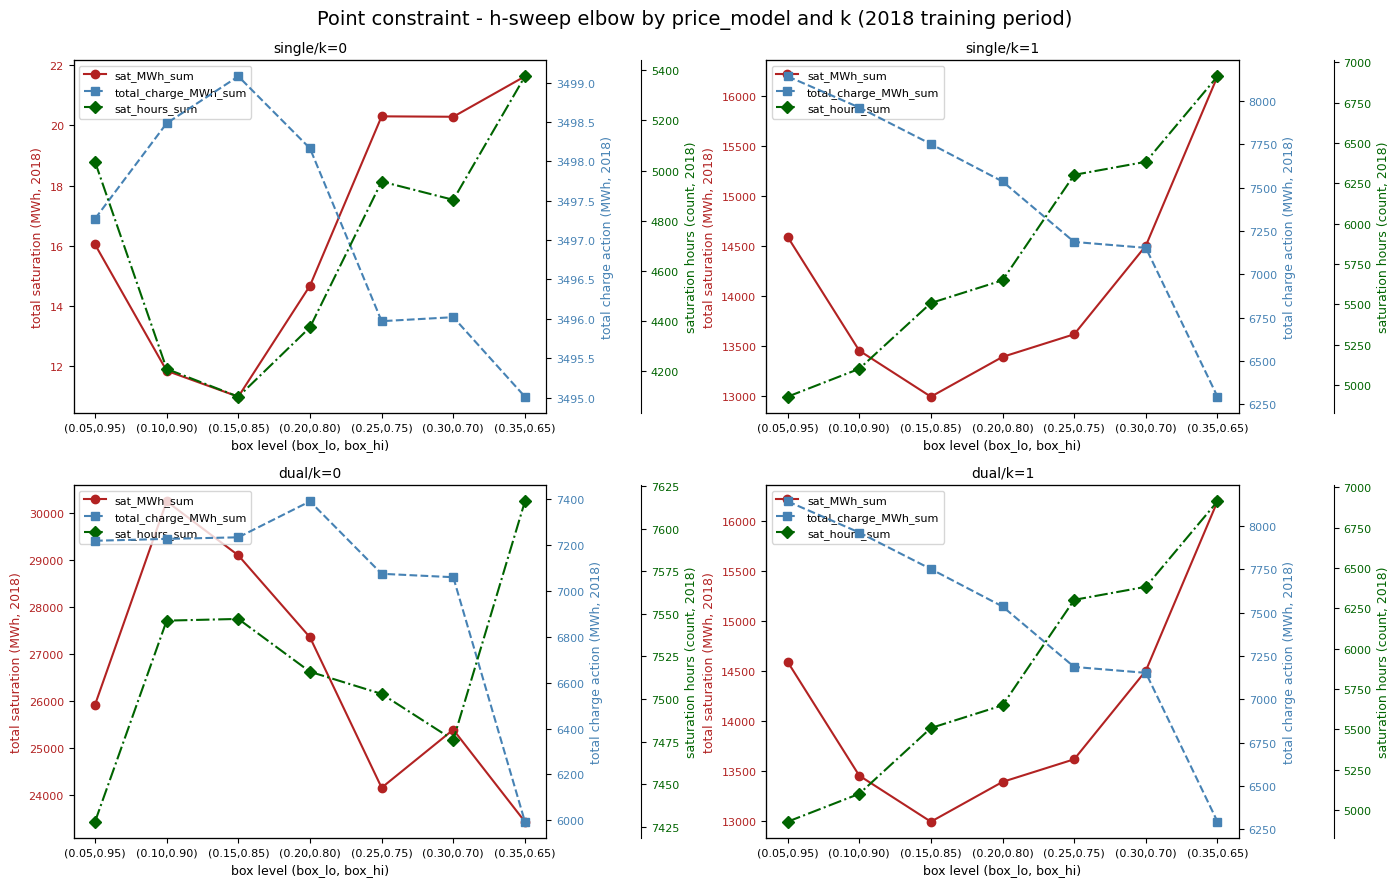

In [15]:
point_yearly_path = MODELS_ROBUST_DIR / "h_sweep_yearly_2018_point.csv"
point_yearly = pd.read_csv(point_yearly_path)
print(f"loaded: {point_yearly_path}")

# k=1 (single==dual by construction in both models) -- the directly comparable slice
robust_k1 = yearly[(yearly["k"] == 1) & (yearly["price_model"] == "single")].sort_values("box_lo")
point_k1 = point_yearly[(point_yearly["k"] == 1) & (point_yearly["price_model"] == "single")].sort_values("box_lo")

plot_spec = [
    ("single", 0),
    ("single", 1),
    ("dual", 0),
    ("dual", 1),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
fig.suptitle("Point constraint - h-sweep elbow by price_model and k (2018 training period)", fontsize=14)

# Reserve extra space on the right side of the figure for the outer twin axes
fig.subplots_adjust(right=0.82, top=0.90, hspace=0.3, wspace=0.3)

for ax, (pm, k) in zip(axes.flat, plot_spec):
    sel = point_yearly[(point_yearly["price_model"] == pm) & (point_yearly["k"] == k)].sort_values("box_lo")
    box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(sel["box_lo"], sel["box_hi"])]

    # Primary y-axis: saturation volume
    ax.plot(box_labels, sel["sat_MWh_sum"], "o-", color="firebrick", label="sat_MWh_sum")
    ax.set_ylabel("total saturation (MWh, 2018)", color="firebrick", fontsize=9)
    ax.tick_params(axis="y", labelcolor="firebrick", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("box level (box_lo, box_hi)", fontsize=9)
    ax.set_title(f"{pm}/k={k}", fontsize=10)

    # Secondary y-axis: charge action
    ax2 = ax.twinx()
    ax2.plot(box_labels, sel["total_charge_MWh_sum"], "s--", color="steelblue", label="total_charge_MWh_sum")
    ax2.set_ylabel("total charge action (MWh, 2018)", color="steelblue", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
    # Disable scientific notation offset (+4.8048e3) to prevent text clutter
    ax2.ticklabel_format(style="plain", axis="y")

    # Third y-axis: saturation hours (pushed further out to 1.20)
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("axes", 1.20))
    ax3.set_frame_on(True)
    ax3.patch.set_visible(False)
    ax3.plot(box_labels, sel["sat_hours_sum"], "D-.", color="darkgreen", label="sat_hours_sum")
    ax3.set_ylabel("saturation hours (count, 2018)", color="darkgreen", fontsize=9)
    ax3.tick_params(axis="y", labelcolor="darkgreen", labelsize=8)
    ax3.ticklabel_format(style="plain", axis="y")

    # Combine handles and labels from all 3 axes into a single legend
    lines, labels = [], []
    for a in [ax, ax2, ax3]:
        h, l = a.get_legend_handles_labels()
        lines.extend(h)
        labels.extend(l)
    
    ax.legend(lines, labels, fontsize=8, loc="upper left")

    """
    # Recommended pick marker: (0.20, 0.80)
    if "(0.20,0.80)" in box_labels:
        pick_idx = box_labels.index("(0.20,0.80)")
        ax.axvline(pick_idx, color="gray", linestyle=":", alpha=0.7)
        ax.annotate(
            "recommended pick\n(0.20, 0.80)",
            xy=(pick_idx, sel["sat_MWh_sum"].iloc[pick_idx]),
            xytext=(pick_idx + 0.3, sel["sat_MWh_sum"].max() * 0.6),
            fontsize=9,
            color="gray",
        )
    """

fig.tight_layout()
plt.show()

loaded: /home/fleet75/diss_bess/6_models/models_robust/h_sweep_yearly_2018_point.csv


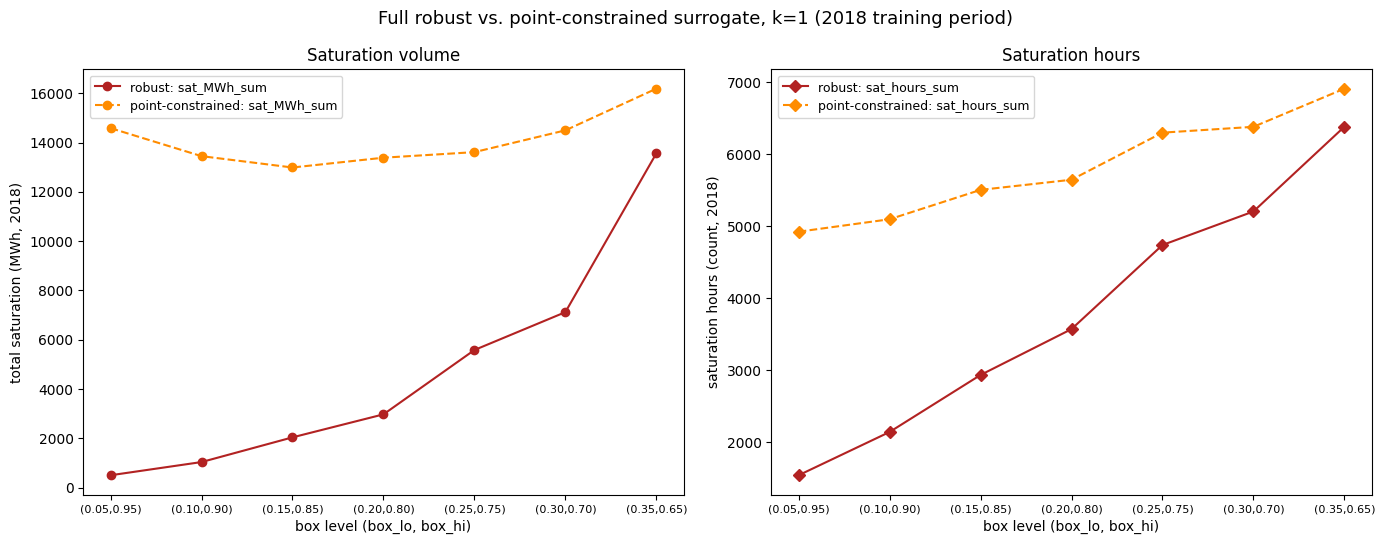


k=1 comparison table:
        box  robust_sat_MWh  point_sat_MWh  robust_sat_hours  point_sat_hours
(0.05,0.95)      499.733009   14590.128544              1544             4927
(0.10,0.90)     1035.391429   13452.948023              2145             5100
(0.15,0.85)     2038.155420   12992.504121              2937             5508
(0.20,0.80)     2971.465806   13390.215369              3574             5649
(0.25,0.75)     5583.197694   13616.222529              4742             6303
(0.30,0.70)     7120.300711   14500.482715              5208             6384
(0.35,0.65)    13563.736449   16192.680816              6385             6914


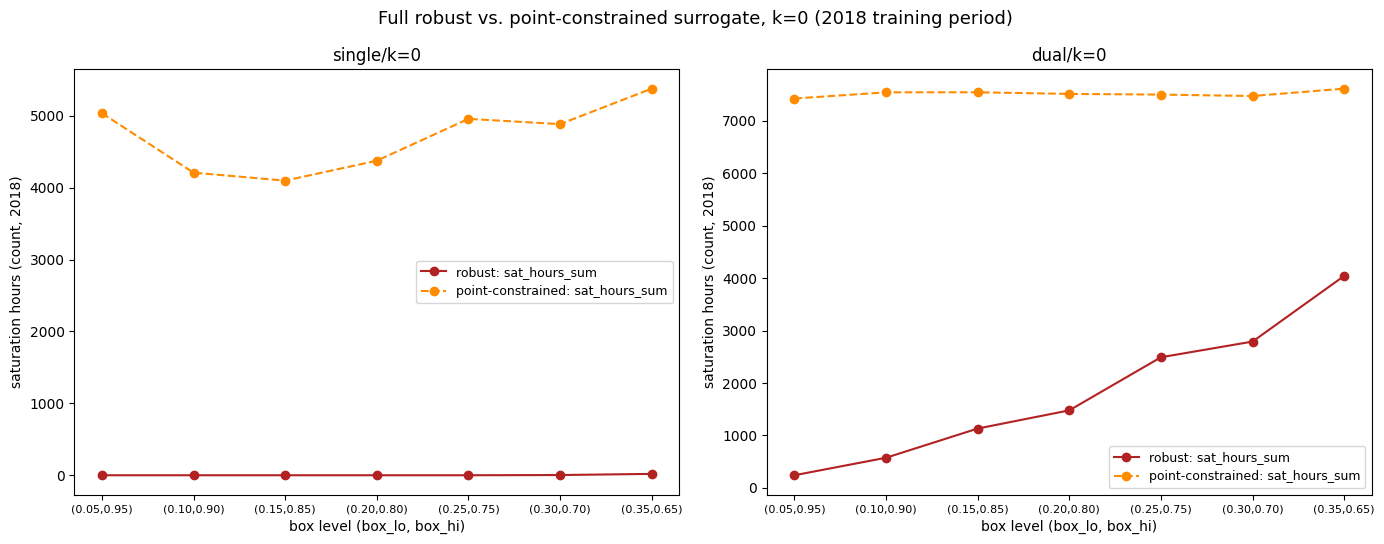

In [16]:
point_yearly_path = MODELS_ROBUST_DIR / "h_sweep_yearly_2018_point.csv"
point_yearly = pd.read_csv(point_yearly_path)
print(f"loaded: {point_yearly_path}")

# k=1 (single==dual by construction in both models) -- the directly comparable slice
robust_k1 = yearly[(yearly["k"] == 1) & (yearly["price_model"] == "single")].sort_values("box_lo")
point_k1 = point_yearly[(point_yearly["k"] == 1) & (point_yearly["price_model"] == "single")].sort_values("box_lo")
box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(robust_k1["box_lo"], robust_k1["box_hi"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Full robust vs. point-constrained surrogate, k=1 (2018 training period)", fontsize=13)

ax = axes[0]
ax.plot(box_labels, robust_k1["sat_MWh_sum"], "o-", color="firebrick", label="robust: sat_MWh_sum")
ax.plot(box_labels, point_k1["sat_MWh_sum"], "o--", color="darkorange", label="point-constrained: sat_MWh_sum")
ax.set_ylabel("total saturation (MWh, 2018)")
ax.set_xlabel("box level (box_lo, box_hi)")
ax.set_title("Saturation volume")
ax.legend(fontsize=9)
ax.tick_params(axis="x", labelsize=8)

ax = axes[1]
ax.plot(box_labels, robust_k1["sat_hours_sum"], "D-", color="firebrick", label="robust: sat_hours_sum")
ax.plot(box_labels, point_k1["sat_hours_sum"], "D--", color="darkorange", label="point-constrained: sat_hours_sum")
ax.set_ylabel("saturation hours (count, 2018)")
ax.set_xlabel("box level (box_lo, box_hi)")
ax.set_title("Saturation hours")
ax.legend(fontsize=9)
ax.tick_params(axis="x", labelsize=8)

fig.tight_layout()
plt.show()

print("\nk=1 comparison table:")
cmp = pd.DataFrame({
    "box": box_labels,
    "robust_sat_MWh": robust_k1["sat_MWh_sum"].values,
    "point_sat_MWh": point_k1["sat_MWh_sum"].values,
    "robust_sat_hours": robust_k1["sat_hours_sum"].values,
    "point_sat_hours": point_k1["sat_hours_sum"].values,
})
print(cmp.to_string(index=False))

# k=0 comparison, both price models -- flat/noisy for the point model, box-sensitive for robust
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Full robust vs. point-constrained surrogate, k=0 (2018 training period)", fontsize=13)
for ax, pm in zip(axes, ["single", "dual"]):
    r = yearly[(yearly["k"] == 0) & (yearly["price_model"] == pm)].sort_values("box_lo")
    p = point_yearly[(point_yearly["k"] == 0) & (point_yearly["price_model"] == pm)].sort_values("box_lo")
    labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(r["box_lo"], r["box_hi"])]
    ax.plot(labels, r["sat_hours_sum"], "o-", color="firebrick", label="robust: sat_hours_sum")
    ax.plot(labels, p["sat_hours_sum"], "o--", color="darkorange", label="point-constrained: sat_hours_sum")
    ax.set_title(f"{pm}/k=0")
    ax.set_xlabel("box level (box_lo, box_hi)")
    ax.set_ylabel("saturation hours (count, 2018)")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()

## Point-constrained comparison: interpretation

The point-constrained surrogate's **best case (widest box, `(0.05,0.95)`) saturates about
as much as the full robust model's *worst* case (narrowest box, `(0.35,0.65)`)**: ~4,927
hours / 14,590 MWh vs. ~6,385 hours / 13,564 MWh. That's the direct, quantified cost of
checking only 2 of `2^T` box vertices instead of the true worst case -- real historical
data routinely lands on combinations the 2-point check never covers, so saturation stays
high almost regardless of box width.

At `k=0` it's worse in a different way: `single/k=0` on the point model sits around
4,100-5,400 sat_hours with no discernible trend across box widths (vs. the robust model's
essentially-zero baseline), and `dual/k=0` is pinned around ~7,500 sat_hours almost flat
across every box level tested. There's no elbow to find here -- box width barely affects
the surrogate's saturation behaviour at k=0 at all.

**Locked-in decision: `(0.15, 0.85)` for both models.** This isn't a "which box"
optimisation problem for the point-constrained model specifically -- it provides
substantially weaker grounding than the full robust model at *every* box width in this
sweep, an inherent property of the 2-vertex approximation rather than something a
different h choice fixes. But `(0.15,0.85)` is still the more precisely-supported choice
on the metrics where the point model IS informative (`sat_MWh`'s minimum for `single/k=0`,
`single/k=1`, and `dual/k=1` sits exactly at `(0.15,0.85)`), and it's the same box already
justified independently on the full robust model's data -- so using it consistently for
both training and final testing avoids introducing a second, separately-justified box
purely for training-time convenience.